# JAFF

The network class is the core class of JAFF. It is resposible for creating the network object which contains all the properties of the network such as reactions, species and related metadata

In [1]:
from jaff import Network

net = Network("../networks/demos/demo1.jet")


░░█ ▄▀█ █▀▀ █▀▀
█▄█ █▀█ █▀░ █▀░

Just Another Flexible Format!

INFO     Loading network from /home/anish/External/programming/research/jaff/worktrees/feature_photo_dissociation/networks/demos/demo1.jet
INFO     Network label: demo1


Output()

Output()

INFO     Variables found: av, crate, tgas
INFO     Loaded 15 reactions
INFO     Loaded 2 photo-chemistry reactions
WARNING  Found undefined functions photorates
INFO     Sink: H2
INFO     Sink: N2+
INFO     Sink: CH2
INFO     Source: CH
WARNING  Sink detected
WARNING  Source detected
WARNING  Electron recombination not found for N2+
INFO     Network loaded successfully!


Now that the network is loaded, we can access different properties of the network using the `net` object

## Specie properties

`Network.species` contains a list of species objects which can be indexed like a normal list.
Each `species` object have theire own attributes like `name` and `mass`

In [2]:
from IPython.display import display, Markdown

table = r"""
| Name | Mass | Charge | Latex |
|------|------|--------|-------|
"""

for specie in net.species:
    table += (
        f"| {specie.name} "
        f"| {specie.mass:.5e} "
        f"| {specie.charge} "
        f"| ${specie.latex()}$ |\n"
    )

display(Markdown(table))


| Name | Mass | Charge | Latex |
|------|------|--------|-------|
| H+ | 1.67377e-24 | 1 | ${\rm H^{+}}$ |
| e- | 9.10938e-28 | -1 | ${\rm e^{-}}$ |
| H | 1.67377e-24 | 0 | ${\rm H}$ |
| C | 1.99447e-23 | 0 | ${\rm C}$ |
| C+ | 1.99447e-23 | 1 | ${\rm C^{+}}$ |
| CO+ | 4.65124e-23 | 1 | ${\rm CO^{+}}$ |
| CO | 4.65124e-23 | 0 | ${\rm CO}$ |
| O | 2.65676e-23 | 0 | ${\rm O}$ |
| CH2 | 2.32923e-23 | 0 | ${\rm CH_{2}}$ |
| CH | 2.16185e-23 | 0 | ${\rm CH}$ |
| N2 | 4.65173e-23 | 0 | ${\rm N_{2}}$ |
| N | 2.32587e-23 | 0 | ${\rm N}$ |
| N2+ | 4.65173e-23 | 1 | ${\rm N_{2}^{+}}$ |
| H2 | 3.34755e-24 | 0 | ${\rm H_{2}}$ |


## Reaction properties

Like `Network.species`, `Network.reactions` stores a list of reactions objects which can be accessed by their respective indices. `Reaction` objects contain their own attributes like `tmin` and `tmax` for the reaction

In [3]:
table = """
| Verbatim | LaTeX |
|----------|-------|
"""

for rxn in net.reactions:
    table += f"| `{rxn.verbatim}` | ${rxn.get_latex()}$ |\n"

display(Markdown(table))


| Verbatim | LaTeX |
|----------|-------|
| `H+ + e- -> H` | $${\rm H^{+}} + {\rm e^{-}}\,\to\,{\rm H}$$ |
| `H -> H+ + e-` | $${\rm H}\,\to\,{\rm H^{+}} + {\rm e^{-}}$$ |
| `C -> C+ + e-` | $${\rm C}\,\to\,{\rm C^{+}} + {\rm e^{-}}$$ |
| `C+ + e- -> C` | $${\rm C^{+}} + {\rm e^{-}}\,\to\,{\rm C}$$ |
| `CO+ + e- -> CO` | $${\rm CO^{+}} + {\rm e^{-}}\,\to\,{\rm CO}$$ |
| `C + O -> CO` | $${\rm C} + {\rm O}\,\to\,{\rm CO}$$ |
| `CO -> C + O` | $${\rm CO}\,\to\,{\rm C} + {\rm O}$$ |
| `CO -> CO+ + e-` | $${\rm CO}\,\to\,{\rm CO^{+}} + {\rm e^{-}}$$ |
| `H -> H+ + e-` | $${\rm H}\,\to\,{\rm H^{+}} + {\rm e^{-}}$$ |
| `CH2 -> CH + H` | $${\rm CH_{2}}\,\to\,{\rm CH} + {\rm H}$$ |
| `N2 -> N + N` | $${\rm N_{2}}\,\to\,{\rm N} + {\rm N}$$ |
| `N + N -> N2` | $${\rm N} + {\rm N}\,\to\,{\rm N_{2}}$$ |
| `CO + N2+ -> N2 + CO+` | $${\rm CO} + {\rm N_{2}^{+}}\,\to\,{\rm N_{2}} + {\rm CO^{+}}$$ |
| `H2 + e- -> H + H + e-` | $${\rm H_{2}} + {\rm e^{-}}\,\to\,{\rm H} + {\rm H} + {\rm e^{-}}$$ |
| `CO + N2+ -> N2 + CO+` | $${\rm CO} + {\rm N_{2}^{+}}\,\to\,{\rm N_{2}} + {\rm CO^{+}}$$ |


Individual reactions can be accessed in the following way

In [4]:
print(f"The first reaction in verbatim form:   {net.reactions[0].verbatim}")  # verbatim name of first reaction
print(f"The firse reaction in serealized form: {net.reactions[0].serialized}")

The first reaction in verbatim form:   H+ + e- -> H
The firse reaction in serealized form: H+_e-__H


The reaction rate coefficients can be accessed in speciefic programming languages using the `get_code` method

In [5]:
print(f"Rate coefficient in c:        {net.reactions[0].get_code(lang='c')}")  # rate in C format of first reaction
print(f"Rate coefficient in fortran:  {net.reactions[0].get_code(lang='fortran')}")  # rate in Fortran 90 format of first reaction

Rate coefficient in c:        2.6022447615079392e-10*pow(fmin(300.0, tgas), -0.75)
Rate coefficient in fortran:        2.60224476150794d-10*min(300.0d0, tgas)**(-0.75d0)


In [6]:
# Check if the first reaction is the same as itself
print(f"Is the first reaction same as the first reaction: {net.reactions[0] == net.reactions[0]}")

# Check if the first reaction is the same as the second
print(f"Is the first reaction same as teh second reaction: {net.reactions[0] == net.reactions[1]}")  

Is the first reaction same as the first reaction: True
Is the first reaction same as teh second reaction: False


Reaction rate coefficients and flux expressions can be also be accessed

In [7]:
# Flux of first reaction in symbolic form
print(f"Flux expression for the first reaction: {net.reactions[0].get_flux_expression(rate_variable="krate")}")  

# Rate of first reaction in symbolic form
print("Rate coefficient for the first reaction: ")
net.reactions[0].rate

Flux expression for the first reaction: krate[0] * y[idx_hj] * y[idx_e]
Rate coefficient for the first reaction: 


2.60224476150794e-10/Min(300.0, tgas)**0.75

Cross-sections of certain photo reactions can also be plotted

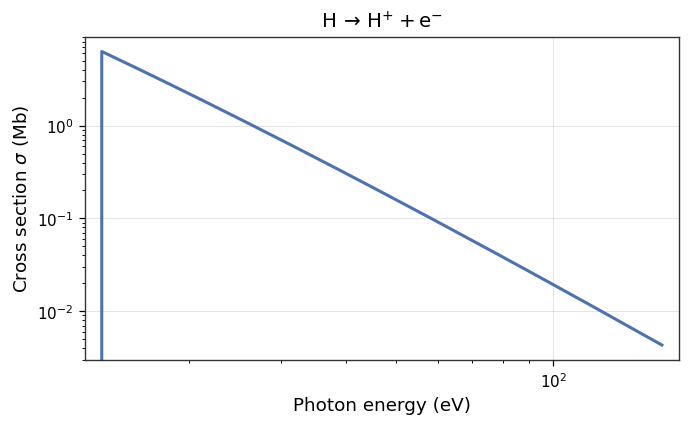

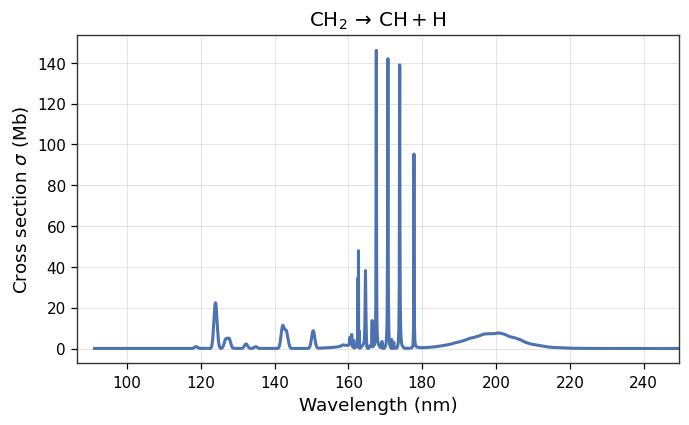

In [8]:
a = net.reactions.get(
    "H -> H+ + e-", rtype="photo"
)  # get reaction by verbatim name
a.plot_xsecs(processes="photo_ionization")

a = net.reactions.get("CH2 -> CH + H")  # get photodissociation reaction
_ = a.plot_xsecs(energy_unit="nm", energy_log=False, xsecs_log=False, processes="photo_dissociation")  # plot cross-sections

## Code generation

Jaff also comes with code generation capabilities and comes with an in-built templating system to generate langauge specific code

In [9]:
! jaffgen --template fortran_dlsodes --network ../networks/demos/demo1.jet --lang fortran


░░█ ▄▀█ █▀▀ █▀▀ █▀▀ █▀▀ █▄░█
█▄█ █▀█ █▀░ █▀░ █▄█ ██▄ █░▀█

Just Another Fragile Format Generator!

WARNING  No output directory has been supplied.
WARNING  Files will be generated at /home/anish/External/programming/research/jaff/worktrees/feature_photo_dissociation/generated
INFO     Loading network from /home/anish/External/programming/research/jaff/worktrees/feature_photo_dissociation/networks/demos/demo1.jet
INFO     Network label: demo1
INFO     Variables found: av, crate, tgas
INFO     Loaded 15 reactions
INFO     Loaded 2 photo-chemistry reactions
WARNING  Found undefined functions photorates
INFO     Sink: H2
INFO     Sink: N2+
INFO     Sink: CH2
INFO     Source: CH
WARNING  Sink detected
WARNING  Source detected
WARNING  Electron recombination not found for N2+
INFO     Network loaded successfully!
INFO     commons.f90 created at /home/anish/External/programming/research/jaff/worktrees/feature_photo_dissociation/generated
INFO     fluxes.f90 created at /home/anish/External/pr

Networks can can also be compared to each other

In [10]:
net2 = Network("../networks/demos/demo2.jet", label="very small network")


░░█ ▄▀█ █▀▀ █▀▀
█▄█ █▀█ █▀░ █▀░

Just Another Flashy Format!

INFO     Loading network from /home/anish/External/programming/research/jaff/worktrees/feature_photo_dissociation/networks/demos/demo2.jet
INFO     Network label: very small network


Output()

Output()

INFO     Variables found: av, tgas
INFO     Loaded 2 reactions
INFO     Loaded 0 photo-chemistry reactions
INFO     Network loaded successfully!


In [11]:
net.compare_reactions(net2)  # compare two networks

INFO     Comparing networks "demo1" and "very small network"...
INFO     Reactions not present in demo1:
 

INFO     Reactions not present in very small network:
H -> H+ + e-
C+ + e- -> C
N2 -> N + N
CO -> C + O
CH2 -> CH + H
C -> C+ + e-
H2 + e- -> H + H + e-
C + O -> CO
N + N -> N2
H+ + e- -> H
CO + N2+ -> N2 + CO+ 

INFO     Reactions present in both demo1 and very small network:
CO+ + e- -> CO
CO -> CO+ + e- 

INFO     2 reactions are common in both networks
INFO     0 reactions are missing in "demo1"
INFO     11 reactions are missing in "very small network"


In [12]:
net.compare_species(net2)  # compare species in two networks

INFO     Comparing species in networks "demo1" and "very small network"...
INFO     Species not present in demo1:
 

INFO     Species not present in very small network:
H, N2, H2, CH2, N, N2+, CH, C, O, H+, C+ 

INFO     Species present in both demo1 and very small network:
CO, e-, CO+ 

INFO     3 species are common in both networks
INFO     0 species are missing in "demo1"
INFO     11 species are missing in "very small network"


Reactions rates can also be plotted

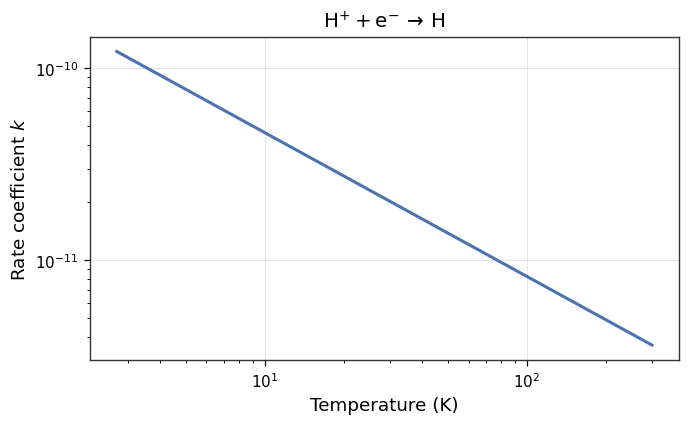

In [14]:
net.reactions[0].rate  # verbatim name of first reaction in COthin network
_ = net.reactions[0].plot_rate_coefficient()